# Fuel Efficiency Predictor


This notebook uses the classic Auto MPG dataset and demonstrates how to build models to predict the fuel efficiency of the late-1970s and early 1980s automobiles. To do this, you will provide the models with a description of many automobiles from that time period. This description includes attributes like cylinders, displacement, horsepower, and weight.

## Packages

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(precision=3, suppress=True)

import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers

print(tf.__version__)

2.19.0


## Load the data

In [2]:
url = 'http://archive.ics.uci.edu/ml/machine-learning-databases/auto-mpg/auto-mpg.data'
column_names = ['MPG', 'Cylinders', 'Displacement', 'Horsepower', 'Weight',
                'Acceleration', 'Model Year', 'Origin']

raw_dataset = pd.read_csv(url, names=column_names,
                          na_values='?', comment='\t',
                          sep=' ', skipinitialspace=True)

In [3]:
dataset = raw_dataset.copy()
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
393,27.0,4,140.0,86.0,2790.0,15.6,82,1
394,44.0,4,97.0,52.0,2130.0,24.6,82,2
395,32.0,4,135.0,84.0,2295.0,11.6,82,1
396,28.0,4,120.0,79.0,2625.0,18.6,82,1
397,31.0,4,119.0,82.0,2720.0,19.4,82,1


In [4]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB


## Clean the data

the data contains a few unknown values that should be dropped .

In [5]:
dataset = dataset.dropna()

## Preprocessing the data

The "Origin" column is categorical, not numeric. So the next step is to one-hot encode the values.

In [6]:
dataset['Origin'] = dataset['Origin'].map({1: 'USA', 2: 'Europe', 3: 'Japan'})
dataset = pd.get_dummies(dataset, columns=['Origin'], prefix='', prefix_sep='')
dataset.tail()

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
393,27.0,4,140.0,86.0,2790.0,15.6,82,False,False,True
394,44.0,4,97.0,52.0,2130.0,24.6,82,True,False,False
395,32.0,4,135.0,84.0,2295.0,11.6,82,False,False,True
396,28.0,4,120.0,79.0,2625.0,18.6,82,False,False,True
397,31.0,4,119.0,82.0,2720.0,19.4,82,False,False,True


## Split the data into train and test set

In [7]:
train_dataset = dataset.sample(frac=0.8, random_state=0)
test_dataset = dataset.drop(train_dataset.index)

## Inspect the data

Review the joint distribution of a few pairs of columns from the training set.

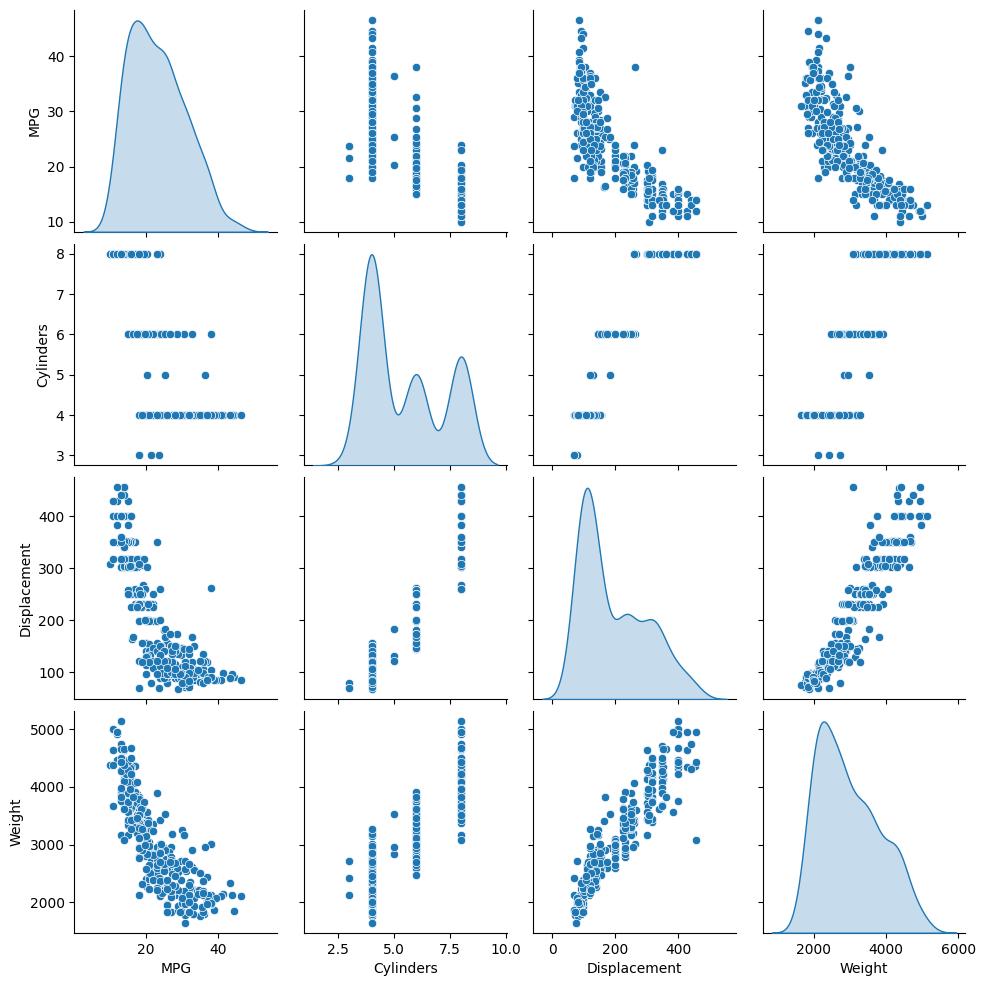

In [8]:
sns.pairplot(train_dataset[['MPG', 'Cylinders', 'Displacement', 'Weight']], diag_kind='kde')

the overal statistics

In [9]:
train_dataset.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
MPG,314.0,23.310510,7.728652,10.0,17.00,22.0,28.95,46.6
Cylinders,314.0,5.477707,1.699788,3.0,4.00,4.0,8.00,8.0
Displacement,314.0,195.318471,104.331589,68.0,105.50,151.0,265.75,455.0
Horsepower,314.0,104.869427,38.096214,46.0,76.25,94.5,128.00,225.0
Weight,314.0,2990.251592,843.898596,1649.0,2256.50,2822.5,3608.00,5140.0
Acceleration,314.0,15.559236,2.789230,8.0,13.80,15.5,17.20,24.8
Model Year,314.0,75.898089,3.675642,70.0,73.00,76.0,79.00,82.0


## Split features from labels
Separate the target value—the "label"—from the features.

In [10]:
train_features = train_dataset.copy()
test_features = test_dataset.copy()

train_labels = train_features.pop('MPG')
test_labels = test_features.pop('MPG')

## Normalization

In [11]:
train_dataset.describe().transpose()[['mean', 'std']]

,mean,std
MPG,23.310510,7.728652
Cylinders,5.477707,1.699788
Displacement,195.318471,104.331589
Horsepower,104.869427,38.096214
Weight,2990.251592,843.898596
Acceleration,15.559236,2.789230
Model Year,75.898089,3.675642


In [12]:
normalizer = tf.keras.layers.Normalization(axis=-1)

In [13]:
normalizer.adapt(np.array(train_features))

In [14]:
print(normalizer.mean.numpy())

[[   5.478  195.318  104.869 2990.252   15.559   75.898    0.178    0.197
     0.624]]


When the layer is called, it returns the input data, with each feature independently normalized:

In [16]:
first = np.array(train_features[:1]).astype(np.float32)

with np.printoptions(precision=2, suppress=True):
  print('First example:', first)
  print()
  print('Normalized:', normalizer(first).numpy())


First example: [[   4.    90.    75.  2125.    14.5   74.     0.     0.     1. ]]

Normalized: [[-0.87 -1.01 -0.79 -1.03 -0.38 -0.52 -0.47 -0.5   0.78]]


## Linear regression

Before building a deep neural network model, start with linear regression using one and several variables.

Linear regression with one variable

Begin with a single-variable linear regression to predict 'MPG' from 'Horsepower'.

steps in single-variable linear regression model:

1. Normalize the 'Horsepower' input features using the tf.keras.layers.Normalization preprocessing layer.

2. Apply a linear transformation to produce 1 output using a linear layer (tf.keras.layers.Dense).


create a NumPy array made of the 'Horsepower' features. Then, instantiate the tf.keras.layers.Normalization and fit its state to the horsepower data:

In [17]:
horsepower = np.array(train_features['Horsepower'])

horsepower_normalizer = layers.Normalization(input_shape=[1,], axis=None)
horsepower_normalizer.adapt(horsepower)

c:\Users\mehri\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\preprocessing\tf_data_layer.py:19: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Build the Keras Sequential model:

In [18]:
horsepower_model = tf.keras.Sequential([
    horsepower_normalizer,
    layers.Dense(units=1)
])

horsepower_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization_1 (Normalization) │ (None, 1)              │             3 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5 (24.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 3 (16.00 B)

 configure the training procedure

In [19]:
horsepower_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

executing the training for 100 epochs:

In [20]:
%%time
history = horsepower_model.fit(
    train_features['Horsepower'],
    train_labels,
    epochs=100,
    verbose=2,
    # Calculate validation results on 20% of the training data.
    validation_split = 0.2)

Epoch 1/100
8/8 - 1s - 151ms/step - loss: 22.8643 - val_loss: 22.9358
Epoch 2/100
8/8 - 0s - 15ms/step - loss: 22.0632 - val_loss: 22.1360
Epoch 3/100
8/8 - 0s - 17ms/step - loss: 21.2617 - val_loss: 21.3360
Epoch 4/100
8/8 - 0s - 14ms/step - loss: 20.4620 - val_loss: 20.5359
Epoch 5/100
8/8 - 0s - 14ms/step - loss: 19.6621 - val_loss: 19.7359
Epoch 6/100
8/8 - 0s - 15ms/step - loss: 18.8644 - val_loss: 18.9361
Epoch 7/100
8/8 - 0s - 16ms/step - loss: 18.0648 - val_loss: 18.1359
Epoch 8/100
8/8 - 0s - 15ms/step - loss: 17.2624 - val_loss: 17.3358
Epoch 9/100
8/8 - 0s - 15ms/step - loss: 16.4629 - val_loss: 16.5360
Epoch 10/100
8/8 - 0s - 14ms/step - loss: 15.6629 - val_loss: 15.7359
Epoch 11/100
8/8 - 0s - 15ms/step - loss: 14.8622 - val_loss: 14.9360
Epoch 12/100
8/8 - 0s - 15ms/step - loss: 14.0618 - val_loss: 14.1360
Epoch 13/100
8/8 - 0s - 15ms/step - loss: 13.2727 - val_loss: 13.3371
Epoch 14/100
8/8 - 0s - 13ms/step - loss: 12.4854 - val_loss: 12.5633
Epoch 15/100
8/8 - 0s - 14ms

Visualize the model's training progress using the stats stored in the history object:

In [21]:
hist = pd.DataFrame(history.history)
hist['epoch'] = history.epoch
hist.tail()

,loss,val_loss,epoch
95,3.803355,4.182430,95
96,3.805388,4.166067,96
97,3.804347,4.180542,97
98,3.803848,4.196405,98
99,3.802577,4.190235,99


In [22]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.ylim([0, 10])
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

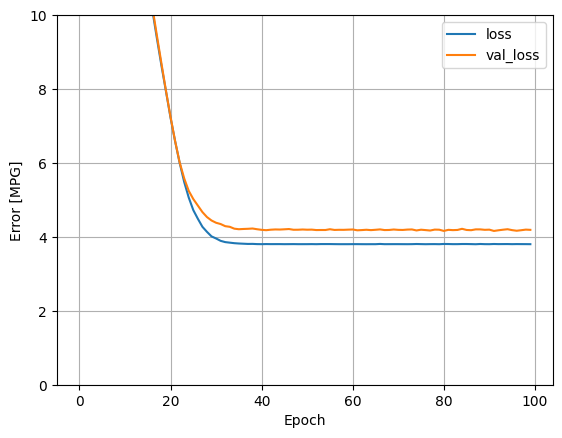

In [23]:
plot_loss(history)

In [25]:
# collect the test set result for the later use 

test_results = {}

test_results['horsepower_model'] = horsepower_model.evaluate(
    test_features['Horsepower'],
    test_labels, verbose=0)

## Linear regression with multiple inputs

In [26]:
linear_model = tf.keras.Sequential([
    normalizer,
    layers.Dense(units=1)
])

linear_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),
    loss='mean_absolute_error')

executing the training for 100 epochs:

In [27]:
%%time
history = linear_model.fit(
    train_features,
    train_labels,
    epochs=100,
    verbose=2,
    validation_split = 0.2)

Epoch 1/100
8/8 - 1s - 116ms/step - loss: 22.9475 - val_loss: 23.0727
Epoch 2/100
8/8 - 0s - 18ms/step - loss: 22.0423 - val_loss: 22.3113
Epoch 3/100
8/8 - 0s - 17ms/step - loss: 21.2478 - val_loss: 21.6175
Epoch 4/100
8/8 - 0s - 14ms/step - loss: 20.4004 - val_loss: 20.8986
Epoch 5/100
8/8 - 0s - 15ms/step - loss: 19.5701 - val_loss: 20.1780
Epoch 6/100
8/8 - 0s - 14ms/step - loss: 18.7631 - val_loss: 19.4530
Epoch 7/100
8/8 - 0s - 15ms/step - loss: 17.9428 - val_loss: 18.7545
Epoch 8/100
8/8 - 0s - 16ms/step - loss: 17.1089 - val_loss: 18.0257
Epoch 9/100
8/8 - 0s - 15ms/step - loss: 16.3122 - val_loss: 17.3138
Epoch 10/100
8/8 - 0s - 15ms/step - loss: 15.4744 - val_loss: 16.5812
Epoch 11/100
8/8 - 0s - 14ms/step - loss: 14.6742 - val_loss: 15.8774
Epoch 12/100
8/8 - 0s - 14ms/step - loss: 13.8686 - val_loss: 15.1758
Epoch 13/100
8/8 - 0s - 15ms/step - loss: 13.0563 - val_loss: 14.4710
Epoch 14/100
8/8 - 0s - 15ms/step - loss: 12.2534 - val_loss: 13.7498
Epoch 15/100
8/8 - 0s - 18ms

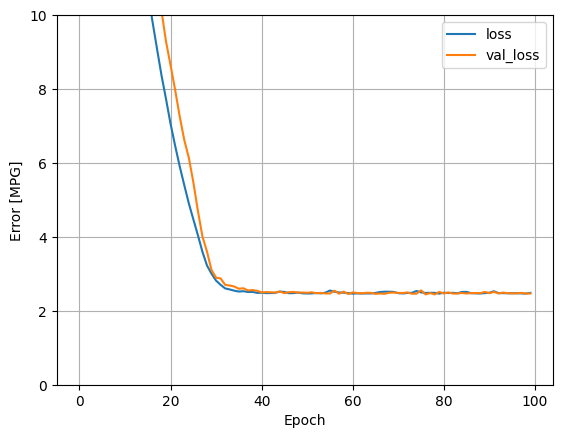

In [28]:
plot_loss(history)

In [29]:
# Collect the results on the test set for later:

test_results['linear_model'] = linear_model.evaluate(
    test_features, test_labels, verbose=0)

## Regression with a deep neural network (DNN)

layers:
1. The normalization layer
2. Two hidden, non-linear, Dense layers with the ReLU (relu) activation function nonlinearity.
3. A linear Dense single-output layer.

structuring the model

In [30]:
def build_and_compile_model(norm):
  model = keras.Sequential([
      norm,
      layers.Dense(64, activation='relu'),
      layers.Dense(64, activation='relu'),
      layers.Dense(1)
  ])

  model.compile(loss='mean_absolute_error',
                optimizer=tf.keras.optimizers.Adam(0.001))
  return model

In [31]:
dnn_model = build_and_compile_model(normalizer)
dnn_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ normalization (Normalization)   │ (None, 9)              │            19 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19 (80.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 19 (80.00 B)

In [33]:
%%time
history = dnn_model.fit(
    train_features,
    train_labels,
    validation_split=0.2,
    verbose=2, epochs=100)

Epoch 1/100


8/8 - 0s - 20ms/step - loss: 2.0264 - val_loss: 2.3276
Epoch 2/100
8/8 - 0s - 15ms/step - loss: 2.0056 - val_loss: 2.3581
Epoch 3/100
8/8 - 0s - 15ms/step - loss: 1.9781 - val_loss: 2.3196
Epoch 4/100
8/8 - 0s - 15ms/step - loss: 1.9883 - val_loss: 2.3352
Epoch 5/100
8/8 - 0s - 14ms/step - loss: 1.9716 - val_loss: 2.3565
Epoch 6/100
8/8 - 0s - 14ms/step - loss: 1.9486 - val_loss: 2.3038
Epoch 7/100
8/8 - 0s - 13ms/step - loss: 1.9450 - val_loss: 2.3562
Epoch 8/100
8/8 - 0s - 17ms/step - loss: 1.9383 - val_loss: 2.3390
Epoch 9/100
8/8 - 0s - 17ms/step - loss: 1.9247 - val_loss: 2.3495
Epoch 10/100
8/8 - 0s - 25ms/step - loss: 1.9196 - val_loss: 2.3408
Epoch 11/100
8/8 - 0s - 15ms/step - loss: 1.9143 - val_loss: 2.3425
Epoch 12/100
8/8 - 0s - 15ms/step - loss: 1.8914 - val_loss: 2.2645
Epoch 13/100
8/8 - 0s - 13ms/step - loss: 1.8866 - val_loss: 2.3191
Epoch 14/100
8/8 - 0s - 15ms/step - loss: 1.8800 - val_loss: 2.2870
Epoch 15/100
8/8 - 0s - 13ms/step - loss: 1.8592 - val_loss: 2.3179
E

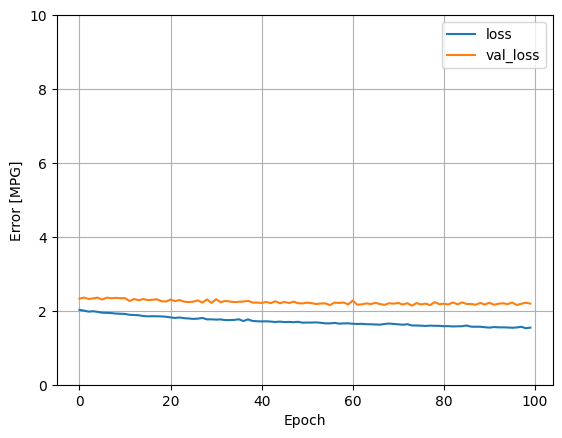

In [34]:
plot_loss(history)

In [35]:
# Collect the results on the test set 

test_results['dnn_model'] = dnn_model.evaluate(test_features, test_labels, verbose=0)

## Performance

In [36]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
horsepower_model,3.641070
linear_model,2.442604
dnn_model,1.753395


## Make predictions

with the dnn_model on the test set

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


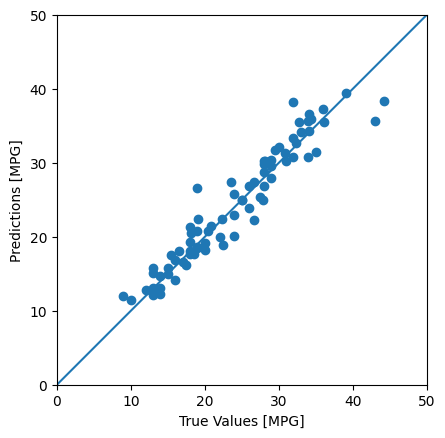

In [37]:
test_predictions = dnn_model.predict(test_features).flatten()

a = plt.axes(aspect='equal')
plt.scatter(test_labels, test_predictions)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
lims = [0, 50]
plt.xlim(lims)
plt.ylim(lims)
_ = plt.plot(lims, lims)

It appears that the model predicts reasonably well.

check the error distribution:

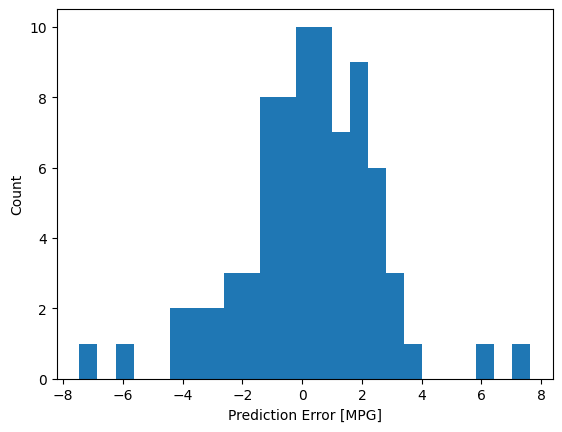

In [38]:
error = test_predictions - test_labels
plt.hist(error, bins=25)
plt.xlabel('Prediction Error [MPG]')
_ = plt.ylabel('Count')

## Save the model

In [39]:
dnn_model.save('dnn_model.keras')

In [40]:
pd.DataFrame(test_results, index=['Mean absolute error [MPG]']).T

,Mean absolute error [MPG]
horsepower_model,3.641070
linear_model,2.442604
dnn_model,1.753395
